<a href="https://colab.research.google.com/github/Leanhchudang2511/baitaptrituenhantao/blob/main/ANNNNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "gradio>=4.30.0"], capture_output=False)

for pkg in ["gradio", "gradio_client", "huggingface_hub"]:
    r = subprocess.run([sys.executable, "-c",
                        f"import {pkg}; print({pkg}.__version__)"],
                       capture_output=True, text=True)
    print(f" {pkg}: {r.stdout.strip()}")

 gradio: 5.50.0
 gradio_client: 1.14.0
 huggingface_hub: 1.16.1


## 📁 Cell 0 — Mount Drive + Load Data
>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print("✅ Drive đã mount! Sẵn sàng lưu/load model.")

Mounted at /content/drive
✅ Drive đã mount! Sẵn sàng lưu/load model.


## 🚀 Cell 1A — Ghi fashion_app.py
> Chạy cell này **trước**, chỉ cần **1 lần**. Dùng `%%writefile` nên không bao giờ bị lỗi encoding.

In [ ]:
%%writefile /content/fashion_app.py
import gradio as gr
import numpy as np
import os, urllib.request, urllib.parse
from PIL import Image

\CLASS_VI = [
    "👕 Áo thun", "👖 Quần dài", "🧥 Áo len", "👗 Váy đầm", "🧥 Áo khoác",
    "👡 Dép sandal", "👔 Áo sơ mi", "👟 Giày thể thao", "👜 Túi xách", "👢 Bốt cổ cao"
]
CLASS_SHORT = ["Áo thun", "Quần dài", "Áo len", "Váy đầm", "Áo khoác",
               "Dép", "Áo sơ mi", "Giày TT", "Túi xách", "Bốt"]

QUICKDRAW_MAP = {
    "t-shirt":    0,
    "pants":      1,
    "sweater":    2,
    "underwear":  3,
    "jacket":     4,
    "flip flops": 5,
    "purse":      6,
    "shoe":       7,
    "backpack":   8,
    "sock":       9,
}

QUICKDRAW_DIR = "/content/drive/MyDrive/quickdraw_cache"
QUICKDRAW_MAX = 5000
BEST_MODEL    = "/content/drive/MyDrive/best_fashion_model.h5"

_model = None
_tf    = None
_keras = {}

def _load_tf():
    global _tf, _keras
    if _tf is not None:
        return
    import tensorflow as tf
    from keras.models import Sequential, load_model
    from keras.layers import Dense, Dropout, BatchNormalization, Flatten
    from keras.utils import to_categorical
    from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
    from keras.datasets import fashion_mnist
    from keras.optimizers import Adam
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    _tf = tf
    _keras = dict(
        Sequential=Sequential, load_model=load_model,
        Dense=Dense, Dropout=Dropout,
        BatchNormalization=BatchNormalization,
        Flatten=Flatten,
        to_categorical=to_categorical,
        EarlyStopping=EarlyStopping,
        ModelCheckpoint=ModelCheckpoint,
        ReduceLROnPlateau=ReduceLROnPlateau,
        fashion_mnist=fashion_mnist,
        Adam=Adam,
        ImageDataGenerator=ImageDataGenerator,
    )

# ── Tải QuickDraw bằng gsutil ─────────────────────────────────────────
def _load_quickdraw(log_list):
    os.makedirs(QUICKDRAW_DIR, exist_ok=True)
    imgs, labels = [], []
    for name, lbl in QUICKDRAW_MAP.items():
        cache_path = os.path.join(QUICKDRAW_DIR, f"{name.replace(' ','_')}.npy")
        if not os.path.exists(cache_path):
            log_list.append(f"  ⬇️  Đang tải: {name}...")
            ret = os.system(f"gsutil -q cp 'gs://quickdraw_dataset/full/numpy_bitmap/{name}.npy' '{cache_path}' 2>/dev/null")
            if ret != 0:
                log_list.append(f"  ❌ Không tải được: {name} — bỏ qua")
                continue
        if not os.path.exists(cache_path):
            continue
        data = np.load(cache_path)
        idx   = np.random.choice(len(data), min(QUICKDRAW_MAX, len(data)), replace=False)
        chunk = data[idx].reshape(-1, 784).astype("float32") / 255.0
        imgs.append(chunk)
        labels.extend([lbl] * len(chunk))
        log_list.append(f"  ✅ {name}: {len(chunk):,} ảnh")
    if not imgs:
        log_list.append("  ⚠️ Không tải được class nào!")
        return np.empty((0, 784)), np.empty((0,))
    return np.concatenate(imgs), np.array(labels)

def _make_generator(x, y_cat, batch_size=256, augment=False):
    k = _keras
    if augment:
        datagen = k["ImageDataGenerator"](
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            rotation_range=10,
            fill_mode="nearest"
        )
        x_img = x.reshape(-1, 28, 28, 1)
        gen   = datagen.flow(x_img, y_cat, batch_size=batch_size, shuffle=True)
        steps = max(1, len(x) // batch_size)
        return gen, steps
    else:
        from keras.utils import Sequence
        class SimpleGen(Sequence):
            def __init__(self, x, y, bs):
                self.x, self.y, self.bs = x, y, bs
                self.indices = np.arange(len(x))
            def __len__(self):
                return max(1, len(self.x) // self.bs)
            def __getitem__(self, i):
                idx = self.indices[i*self.bs:(i+1)*self.bs]
                return self.x[idx], self.y[idx]
            def on_epoch_end(self):
                np.random.shuffle(self.indices)
        return SimpleGen(x, y_cat, batch_size), max(1, len(x) // batch_size)

def _preprocess(pil_img):
    img = pil_img.convert("L")
    w, h = img.size
    s = min(w, h)
    img = img.crop(((w-s)//2, (h-s)//2, (w+s)//2, (h+s)//2))
    img = img.resize((28, 28), Image.LANCZOS)
    arr = np.array(img, dtype="float32") / 255.0
    if np.median(arr) > 0.3:
        arr = 1.0 - arr
    arr = (arr > 0.25).astype("float32")
    return arr

def _prepare_input(arr):
    """arr shape (28,28) → reshape đúng theo model đang load"""
    if _model.input_shape[-1] == 1:
        return arr.reshape(1, 28, 28, 1)
    else:
        return arr.reshape(1, 784)

def _make_bar(preds):
    lines = []
    for i, p in enumerate(preds):
        bar = "█" * int(p * 30)
        lines.append(f"{CLASS_SHORT[i]:8s} {bar} {p*100:.1f}%")
    return "\n".join(lines)

MODEL_CFGS = {
    "Model A — Basic (512→256)":         {"name": "ModelA", "layers": [512, 256],       "dropout": 0.3, "bn": False},
    "Model B — Deeper (512→256→128)+BN": {"name": "ModelB", "layers": [512, 256, 128],  "dropout": 0.3, "bn": True},
    "Model C — Wide (1024→512→256)+BN":  {"name": "ModelC", "layers": [1024, 512, 256], "dropout": 0.4, "bn": True},
}

def _build_model(cfg, k, use_augment):
    m = k["Sequential"](name=cfg["name"])
    if use_augment:
        m.add(k["Flatten"](input_shape=(28, 28, 1)))
    else:
        m.add(k["Dense"](cfg["layers"][0], activation="relu", input_shape=(784,)))
        if cfg["bn"]:
            m.add(k["BatchNormalization"]())
        m.add(k["Dropout"](cfg["dropout"]))
        for u in cfg["layers"][1:]:
            m.add(k["Dense"](u, activation="relu"))
            if cfg["bn"]:
                m.add(k["BatchNormalization"]())
            m.add(k["Dropout"](cfg["dropout"] * 0.7))
        m.add(k["Dense"](10, activation="softmax"))
        m.compile(optimizer=k["Adam"](learning_rate=1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])
        return m

    m.add(k["Dense"](cfg["layers"][0], activation="relu"))
    if cfg["bn"]:
        m.add(k["BatchNormalization"]())
    m.add(k["Dropout"](cfg["dropout"]))
    for u in cfg["layers"][1:]:
        m.add(k["Dense"](u, activation="relu"))
        if cfg["bn"]:
            m.add(k["BatchNormalization"]())
        m.add(k["Dropout"](cfg["dropout"] * 0.7))
    m.add(k["Dense"](10, activation="softmax"))
    m.compile(optimizer=k["Adam"](learning_rate=1e-3),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def fn_train(cfg_name, epochs, use_quickdraw, use_augment, progress=gr.Progress()):
    global _model
    _load_tf()
    k = _keras

    progress(0, desc="Đang tải Fashion MNIST...")
    (x_tr, y_tr), (x_te, y_te) = k["fashion_mnist"].load_data()
    x_tr = x_tr.reshape(-1, 784).astype("float32") / 255.0
    x_te = x_te.reshape(-1, 784).astype("float32") / 255.0

    log = [f"📊 Fashion MNIST: {len(x_tr):,} train | {len(x_te):,} test"]

    if use_quickdraw:
        log.append("\n🎨 Đang tải QuickDraw dataset...")
        yield "\n".join(log), gr.update(visible=False)
        qx, qy = _load_quickdraw(log)
        if len(qx) > 0:
            x_tr = np.concatenate([x_tr, qx])
            y_tr = np.concatenate([y_tr, qy])
            log.append(f"✅ Sau QuickDraw: {len(x_tr):,} ảnh")
    else:
        log.append("⏭️  Bỏ qua QuickDraw")

    y_tr_cat = k["to_categorical"](y_tr, 10)
    y_te_cat = k["to_categorical"](y_te, 10)

    aug_note = " + augment realtime (generator)" if use_augment else ""
    log.append(f"\n📦 Tổng data train: {len(x_tr):,} ảnh{aug_note}")
    yield "\n".join(log), gr.update(visible=False)

    cfgs = MODEL_CFGS if cfg_name == "🔵 Train TẤT CẢ" else {cfg_name: MODEL_CFGS[cfg_name]}
    best_acc = 0

    for cfg_k, cfg in cfgs.items():
        log.append(f"\n🔧 Training {cfg_k}...")
        yield "\n".join(log), gr.update(visible=False)

        m = _build_model(cfg, k, use_augment)
        gen, steps = _make_generator(x_tr, y_tr_cat, batch_size=256, augment=use_augment)

        # validation_data cũng cần đúng shape
        if use_augment:
            val_data = (x_te.reshape(-1, 28, 28, 1), y_te_cat)
        else:
            val_data = (x_te, y_te_cat)

        cbs = [
            k["EarlyStopping"](monitor="val_accuracy", patience=6, restore_best_weights=True),
            k["ModelCheckpoint"](BEST_MODEL, monitor="val_accuracy", save_best_only=True, verbose=0),
            k["ReduceLROnPlateau"](monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=0),
        ]

        hist = m.fit(
            gen,
            steps_per_epoch=steps,
            validation_data=val_data,
            epochs=epochs,
            callbacks=cbs,
            verbose=0
        )
        val_acc = max(hist.history.get("val_accuracy", [0]))
        log.append(f"  ✅ val_accuracy: {val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            _model = m

    log.append(f"\n🏆 Xong! Best val_accuracy: {best_acc:.4f}")
    log.append(f"💾 Model lưu: {BEST_MODEL}")
    yield "\n".join(log), gr.update(value=f"✅ {_model.name} | acc: {best_acc:.4f}", visible=True)

def fn_load_best():
    global _model
    if not os.path.exists(BEST_MODEL):
        return "❌ Chưa có model. Hãy train trước!", gr.update(visible=False)
    _load_tf()
    _model = _keras["load_model"](BEST_MODEL)
    return f"✅ Đã load: {_model.name}", gr.update(value=f"✅ {_model.name}", visible=True)

def fn_upload_h5(file):
    global _model
    if file is None:
        return "❌ Chưa chọn file", gr.update(visible=False)
    _load_tf()
    _model = _keras["load_model"](file.name)
    return f"✅ Đã load: {_model.name}", gr.update(value=f"✅ {_model.name}", visible=True)

def fn_evaluate():
    if _model is None:
        return "❌ Chưa có model!"
    _load_tf()
    k = _keras
    (_, _), (x_te, y_te) = k["fashion_mnist"].load_data()
    x_te = x_te.reshape(-1, 784).astype("float32") / 255.0
    y_cat = k["to_categorical"](y_te, 10)

    if _model.input_shape[-1] == 1:
        x_eval = x_te.reshape(-1, 28, 28, 1)
    else:
        x_eval = x_te

    loss, acc = _model.evaluate(x_eval, y_cat, verbose=0)
    preds = np.argmax(_model.predict(x_eval, verbose=0), axis=1)
    lines = [f"Test Accuracy: {acc:.4f}  |  Loss: {loss:.4f}\n"]
    for i, name in enumerate(CLASS_SHORT):
        mask = y_te == i
        a = (preds[mask] == i).mean() * 100 if mask.sum() > 0 else 0
        bar = "█" * int(a / 5)
        lines.append(f"{name:8s} {bar:20s} {a:.1f}%")
    return "\n".join(lines)

def fn_predict_upload(img):
    if _model is None:
        return "❌ Chưa có model — hãy Train hoặc Load trước!", None
    if img is None:
        return "❌ Chưa chọn ảnh!", None
    pil = Image.fromarray(img) if isinstance(img, np.ndarray) else img
    arr = _preprocess(pil)

    inp   = _prepare_input(arr)
    preds = _model.predict(inp, verbose=0)[0]
    top   = int(np.argmax(preds))
    conf  = float(preds[top]) * 100
    result  = f"🎯 {CLASS_VI[top]}\n📊 Độ tin cậy: {conf:.1f}%\n\n{_make_bar(preds)}"
    preview = Image.fromarray((arr * 255).astype(np.uint8)).resize((140, 140), Image.NEAREST)
    return result, preview

def fn_predict_sketch(img):
    if _model is None:
        return "❌ Chưa có model — hãy Train hoặc Load trước!", None
    if img is None:
        return "❌ Chưa vẽ gì!", None
    if isinstance(img, dict):
        img = img.get("composite") or img.get("layers", [None])[0]
    if img is None:
        return "❌ Chưa vẽ gì!", None
    pil = Image.fromarray(img) if isinstance(img, np.ndarray) else img
    arr = _preprocess(pil)
    inp   = _prepare_input(arr)
    preds = _model.predict(inp, verbose=0)[0]
    top   = int(np.argmax(preds))
    conf  = float(preds[top]) * 100
    result  = f"🎯 {CLASS_VI[top]}\n📊 Độ tin cậy: {conf:.1f}%\n\n{_make_bar(preds)}"
    preview = Image.fromarray((arr * 255).astype(np.uint8)).resize((140, 140), Image.NEAREST)
    return result, preview

with gr.Blocks(title="Fashion AI — MNIST + QuickDraw", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        "# 👗 Fashion AI — MNIST + QuickDraw\n"
        "> ANN với BatchNorm + ReduceLR + Generator Augment + QuickDraw"
    )

    model_status = gr.Textbox(value="❌ Chưa có model", label="Trạng thái Model", interactive=False)

    with gr.Tabs():

        with gr.Tab("🏋️ Train"):
            gr.Markdown("### Train ANN — Fashion MNIST + QuickDraw + Generator Augment")
            with gr.Row():
                cfg_dd = gr.Dropdown(
                    choices=list(MODEL_CFGS.keys()) + ["🔵 Train TẤT CẢ"],
                    value="Model C — Wide (1024→512→256)+BN",
                    label="Cấu hình model"
                )
                ep_sl = gr.Slider(1, 50, value=15, step=1, label="Epochs tối đa")
            with gr.Row():
                use_qd  = gr.Checkbox(value=True, label="🎨 Gộp QuickDraw (5,000 ảnh/class)")
                use_aug = gr.Checkbox(value=True, label="🔄 Generator Augment (không tốn RAM)")
            btn_train = gr.Button("🚀 Bắt đầu Train", variant="primary")
            train_log = gr.Textbox(label="Log", lines=20, interactive=False)
            btn_train.click(
                fn_train,
                inputs=[cfg_dd, ep_sl, use_qd, use_aug],
                outputs=[train_log, model_status]
            )

        with gr.Tab("📂 Load Model"):
            gr.Markdown("### Load model đã train (.h5)")
            with gr.Row():
                btn_load = gr.Button("📂 Load model mới nhất từ Drive", variant="primary")
                btn_eval = gr.Button("📊 Đánh giá test set")
            load_status = gr.Textbox(label="Trạng thái", interactive=False)
            eval_out    = gr.Textbox(label="Kết quả đánh giá", lines=13, interactive=False)
            h5_upload   = gr.File(label="Hoặc upload file .h5", file_types=[".h5", ".keras"])
            btn_load.click(fn_load_best, outputs=[load_status, model_status])
            btn_eval.click(fn_evaluate, outputs=[eval_out])
            h5_upload.change(fn_upload_h5, inputs=[h5_upload], outputs=[load_status, model_status])

        with gr.Tab("🖼️ Upload Ảnh"):
            gr.Markdown("### Upload ảnh — model tự nhận nền sáng/tối")
            with gr.Row():
                img_in = gr.Image(label="Ảnh đầu vào", type="pil", height=400)
                with gr.Column():
                    pred_out = gr.Textbox(label="Kết quả", lines=14, interactive=False)
                    preview  = gr.Image(label="28×28 model thấy", height=140, width=140)
            btn_pred = gr.Button("🎯 Dự đoán", variant="primary")
            btn_pred.click(fn_predict_upload, inputs=[img_in], outputs=[pred_out, preview])

        with gr.Tab("✏️ Vẽ Tay"):
            gr.Markdown(
                "### Vẽ trang phục\n"
                "> 💡 **Màu ĐEN** — tô **đặc** toàn bộ hình, nét **to**, chiếm **70%+ canvas**\n"
                "> ✅ Tô đặc như bóng (silhouette), không vẽ viền outline\n"
                "> ⚠️ Không dùng màu đỏ/xanh — mất thông tin khi chuyển grayscale\n"
                "> 📌 Đã train QuickDraw + Generator Augment — nhận tốt hơn nhiều!"
            )
            with gr.Row():
                with gr.Column(scale=2):
                    sketch = gr.Sketchpad(
                        label="Vẽ tại đây (dùng màu ĐEN, tô đặc)",
                        type="pil",
                        height=500,
                        brush=gr.Brush(
                            default_size=20,
                            colors=["#000000", "#111111", "#222222",
                                    "#333333", "#444444", "#555555"],
                            color_mode="fixed"
                        )
                    )
                with gr.Column(scale=1):
                    draw_out  = gr.Textbox(label="Kết quả", lines=14, interactive=False)
                    draw_prev = gr.Image(label="28×28 model thấy", height=140, width=140)
            btn_draw = gr.Button("🎯 Nhận dạng", variant="primary", size="lg")
            btn_draw.click(fn_predict_sketch, inputs=[sketch], outputs=[draw_out, draw_prev])

if __name__ == "__main__":
    demo.launch(server_name="0.0.0.0", server_port=7860, share=False, show_error=True)

Overwriting /content/fashion_app.py


## 🔗 Cell 1B — Khởi động App + ngrok
> Chạy sau Cell 1A. Mỗi lần muốn mở lại app thì chỉ cần chạy cell này.

In [ ]:


  NGROK_TOKEN = "3DFvCJVYwIGdAyqwiLEDuaBONez_29crAqnArhG8sbtsvXpC3"

  import subprocess, sys, socket, time
  from IPython.display import display, HTML

  print("📦 Kiểm tra thư viện...")
  subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                  "gradio>=4.0", "pyngrok", "pillow", "pandas"], capture_output=True)
  print("✅ Sẵn sàng!")

  import os
  if not os.path.exists("/content/fashion_app.py"):
      raise FileNotFoundError("❌ Không tìm thấy /content/fashion_app.py — hãy chạy Cell 1A trước!")

  subprocess.run(["pkill", "-f", "fashion_app.py"], capture_output=True)
  time.sleep(2)

  print("🚀 Đang khởi động Gradio...")
  proc = subprocess.Popen(
      [sys.executable, "/content/fashion_app.py"],
      stdout=open("/tmp/app_out.log", "w"),
      stderr=open("/tmp/app_err.log", "w")
  )

  print("⏳ Đợi Gradio lắng nghe port 7860", end="", flush=True)
  started = False
  for _ in range(600):
      time.sleep(1)
      print(".", end="", flush=True)
      try:
          with socket.create_connection(("127.0.0.1", 7860), timeout=1):
              started = True
              break
      except:
          pass
  print()

  if not started:
      print("❌ Gradio không khởi động được!")
      out = open("/tmp/app_out.log").read().strip()
      err = open("/tmp/app_err.log").read().strip()
      print("STDOUT:", out[-2000:] if out else "(trống)")
      print("STDERR:", err[-2000:] if err else "(trống)")
      proc.kill()
  else:
      print("✅ Gradio đang chạy tại port 7860!")

      url = None
      if not NGROK_TOKEN.strip():
          print("\n⚠️  NGROK_TOKEN trống — dùng share=True thay thế...")

          proc.kill()
          time.sleep(1)
          subprocess.Popen(
              [sys.executable, "-c",
              "import gradio as gr; exec(open('/content/fashion_app.py').read()); "
              "demo.launch(server_name='0.0.0.0', server_port=7860, share=True, show_error=True)"],
              stdout=open("/tmp/app_share.log", "w"),
              stderr=subprocess.STDOUT
          )
          print("⏳ Đợi link share.gradio.live...", end="", flush=True)
          for _ in range(60):
              time.sleep(2)
              print(".", end="", flush=True)
              try:
                  log = open("/tmp/app_share.log").read()
                  if "gradio.live" in log or "Running on public URL" in log:
                      for line in log.split("\n"):
                          if "gradio.live" in line or "Running on public URL" in line:
                              url = line.strip().split()[-1]
                              break
                      break
              except:
                  pass
          print()
      else:
          try:
              from pyngrok import ngrok, conf
              ngrok.kill()
              time.sleep(2)
              conf.get_default().auth_token = NGROK_TOKEN
              tunnel = ngrok.connect(7860, bind_tls=True)
              url = tunnel.public_url
              print(f"✅ ngrok URL: {url}")
          except Exception as e:
              print(f"❌ ngrok lỗi: {e}")

      if url:
          display(HTML(
              f'<div style="background:linear-gradient(135deg,#1a73e8,#0d47a1);color:#fff;'
              f'padding:24px;border-radius:14px;font-family:sans-serif;margin-top:12px;">'
              f'<div style="font-size:20px;font-weight:700;margin-bottom:12px;">✅ App đang chạy!</div>'
              f'<a href="{url}" target="_blank" style="background:#fff;color:#1a73e8;'
              f'padding:14px 28px;border-radius:10px;font-weight:700;text-decoration:none;font-size:18px;">'
              f'🔗 {url}</a></div>'
          ))
      else:
          display(HTML(
              '<div style="background:#db4437;color:#fff;padding:20px;border-radius:10px;">'
              '<b>❌ Không tạo được link.</b><br><br>'
              'Cách 1: Điền <b>NGROK_TOKEN</b> ở trên → lấy tại <a href="https://dashboard.ngrok.com/authtokens" target="_blank" style="color:#fff;">dashboard.ngrok.com</a><br>'
              'Cách 2: Để trống token, app sẽ tự dùng gradio.live (chậm hơn)'
              '</div>'
          ))


📦 Kiểm tra thư viện...
✅ Sẵn sàng!
🚀 Đang khởi động Gradio...
⏳ Đợi Gradio lắng nghe port 7860.....
✅ Gradio đang chạy tại port 7860!
✅ ngrok URL: https://bruising-slideshow-chapped.ngrok-free.dev


## 🔧 Cell 2 — Import & Cấu hình
> Chạy trước Cell 3–10 nếu dùng notebook thuần (không dùng Streamlit)

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Import thư viện + Cấu hình                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import os
import glob
import re
import base64
import json
import io
import pandas as pd
from PIL import Image
from IPython.display import display, HTML, Javascript, clear_output
import ipywidgets as widgets
from google.colab import files, output

# TF lazy import — chỉ load khi cần (tiết kiệm ~10-15s khi chạy Cell 2)
print('⏳ Import TensorFlow (lần đầu ~15s)...')
import tensorflow as tf
from keras.datasets import fashion_mnist
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, EarlyStopping
tf.config.optimizer.set_jit(True)            # XLA JIT — tăng tốc train ~10-20%
tf.config.threading.set_inter_op_parallelism_threads(2)  # tối ưu CPU threads

# ── Nhãn ─────────────────────────────────────────────────────────────
CLASS_NAMES_VI = [
    '👕 Áo thun','👖 Quần dài','🧥 Áo len chui','👗 Váy đầm','🧥 Áo khoác',
    '👡 Dép sandal','👔 Áo sơ mi','👟 Giày thể thao','👜 Túi xách','👢 Bốt cổ cao'
]
CLASS_NAMES_EN = [
    'T-shirt/top','Trouser','Pullover','Dress','Coat',
    'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]
CLASS_NAMES_SHORT = [
    'Áo thun','Quần dài','Áo len','Váy đầm','Áo khoác',
    'Dép','Áo sơ mi','Giày TT','Túi xách','Bốt'
]

# ── Keyword mapping để đoán nhãn ─────────────────────────────────────
KEYWORD_MAP = {
    0: ['tshirt','t-shirt','t shirt','tee','tank','top','ao thun'],
    1: ['trouser','pant','pants','jeans','denim','legging','shorts','bottom','quan'],
    2: ['pullover','sweater','sweatshirt','hoodie','cardigan','ao len'],
    3: ['dress','skirt','vay','dam','romper','jumpsuit'],
    4: ['coat','jacket','blazer','outerwear','ao khoac'],
    5: ['sandal','slipper','flip flop','dep'],
    6: ['shirt','blouse','woven','tunic','ao so mi','button'],
    7: ['sneaker','shoe','trainer','runner','giay','athletic','footwear'],
    8: ['bag','backpack','handbag','purse','tote','clutch','tui'],
    9: ['ankle','boot','bootie','bot'],
}

# ── Biến toàn cục ─────────────────────────────────────────────────────
model = None
all_train_results = []
best_model_path = '/content/best_fashion_model.h5'
DATA_DIR = '/content/fashion_data'
styles_map = {}  # id → articleType từ styles.csv

# ── Hàm tiện ích ─────────────────────────────────────────────────────
def guess_label(path):
    """Đoán nhãn từ tên file/folder hoặc articleType"""
    p = str(path).lower().replace('-',' ').replace('_',' ')
    for label, kws in KEYWORD_MAP.items():
        for kw in kws:
            if kw in p:
                return label
    return None

def img_to_28x28(path_or_pil):
    """Đọc ảnh → grayscale 28×28 → float32 [0,1]"""
    if isinstance(path_or_pil, str):
        img = Image.open(path_or_pil).convert('L')
    else:
        img = path_or_pil.convert('L')
    w, h = img.size
    s = min(w, h)
    img = img.crop(((w-s)//2,(h-s)//2,(w+s)//2,(h+s)//2))
    img = img.resize((28,28), Image.LANCZOS)
    arr = np.array(img, dtype='float32') / 255.0
    if arr.mean() > 0.5:
        arr = 1.0 - arr
    return arr

def predict_image(img_array_or_pil):
    """Dự đoán ảnh, trả về (preds, img_28x28)"""
    if model is None:
        print('❌ Chưa có model!')
        return None, None
    if isinstance(img_array_or_pil, np.ndarray):
        if img_array_or_pil.ndim == 3:
            gray = cv2.cvtColor(img_array_or_pil, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_array_or_pil
        img28 = cv2.resize(gray, (28,28)).astype('float32')/255.0
        if img28.mean() > 0.5: img28 = 1.0 - img28
    else:
        img28 = img_to_28x28(img_array_or_pil)
    preds = model.predict(img28.reshape(1,784), verbose=0)[0]
    return preds, img28

def show_prediction(preds, img_orig, img28, title='Kết quả'):
    if preds is None: return
    top = np.argmax(preds)
    conf = preds[top]*100
    fig = plt.figure(figsize=(16,5))
    ax1 = fig.add_subplot(1,3,1)
    if isinstance(img_orig, np.ndarray):
        ax1.imshow(img_orig if img_orig.ndim==3 else img_orig, cmap='gray' if img_orig.ndim==2 else None)
    ax1.set_title('Ảnh gốc'); ax1.axis('off')
    ax2 = fig.add_subplot(1,3,2)
    ax2.imshow(img28, cmap='gray')
    ax2.set_title('28×28 input'); ax2.axis('off')
    ax3 = fig.add_subplot(1,3,3)
    colors = ['#FF6B6B' if i==top else '#4ECDC4' for i in range(10)]
    bars = ax3.barh(CLASS_NAMES_VI, preds*100, color=colors)
    ax3.set_xlabel('Xác suất (%)')
    ax3.set_title('Xác suất từng loại')
    ax3.set_xlim(0,100)
    for bar,p in zip(bars,preds):
        if p>0.02: ax3.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{p*100:.1f}%', va='center', fontsize=8)
    fig.suptitle(f'🎯 {CLASS_NAMES_VI[top]} ({conf:.1f}%)', fontsize=15, fontweight='bold',
                 color='darkgreen' if conf>70 else 'darkorange')
    plt.tight_layout()
    plt.savefig('/content/pred_result.png', dpi=100)
    plt.show()
    print(f'\n🎯 {CLASS_NAMES_VI[top]} ({conf:.1f}%)')
    print('\nTop 3:')
    for i, idx in enumerate(np.argsort(preds)[::-1][:3]):
        print(f'  {i+1}. {CLASS_NAMES_VI[idx]}: {preds[idx]*100:.1f}%')

print(f'✅ Import thành công! TensorFlow {tf.__version__}')
print(f'📁 DATA_DIR: {DATA_DIR}')

⏳ Import TensorFlow (lần đầu ~15s)...
✅ Import thành công! TensorFlow 2.20.0
📁 DATA_DIR: /content/fashion_data


## 📊 Cell 3 — Xem mẫu dữ liệu Fashion MNIST

📥 Đang tải Fashion MNIST...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Train: (60000, 28, 28) | Test: (10000, 28, 28)


/tmp/ipykernel_2062/2111336351.py:12: UserWarning: Glyph 128098 (\N{WOMANS BOOTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2062/2111336351.py:12: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2062/2111336351.py:12: UserWarning: Glyph 128087 (\N{DRESS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2062/2111336351.py:12: UserWarning: Glyph 129509 (\N{COAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2062/2111336351.py:12: UserWarning: Glyph 128095 (\N{ATHLETIC SHOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2062/2111336351.py:12: UserWarning: Glyph 128097 (\N{WOMANS SANDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2062/2111336351.py:12: UserWarning: Glyph 128086 (\N{JEANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2062/2111336351.py:12: UserWarning: Glyph 12

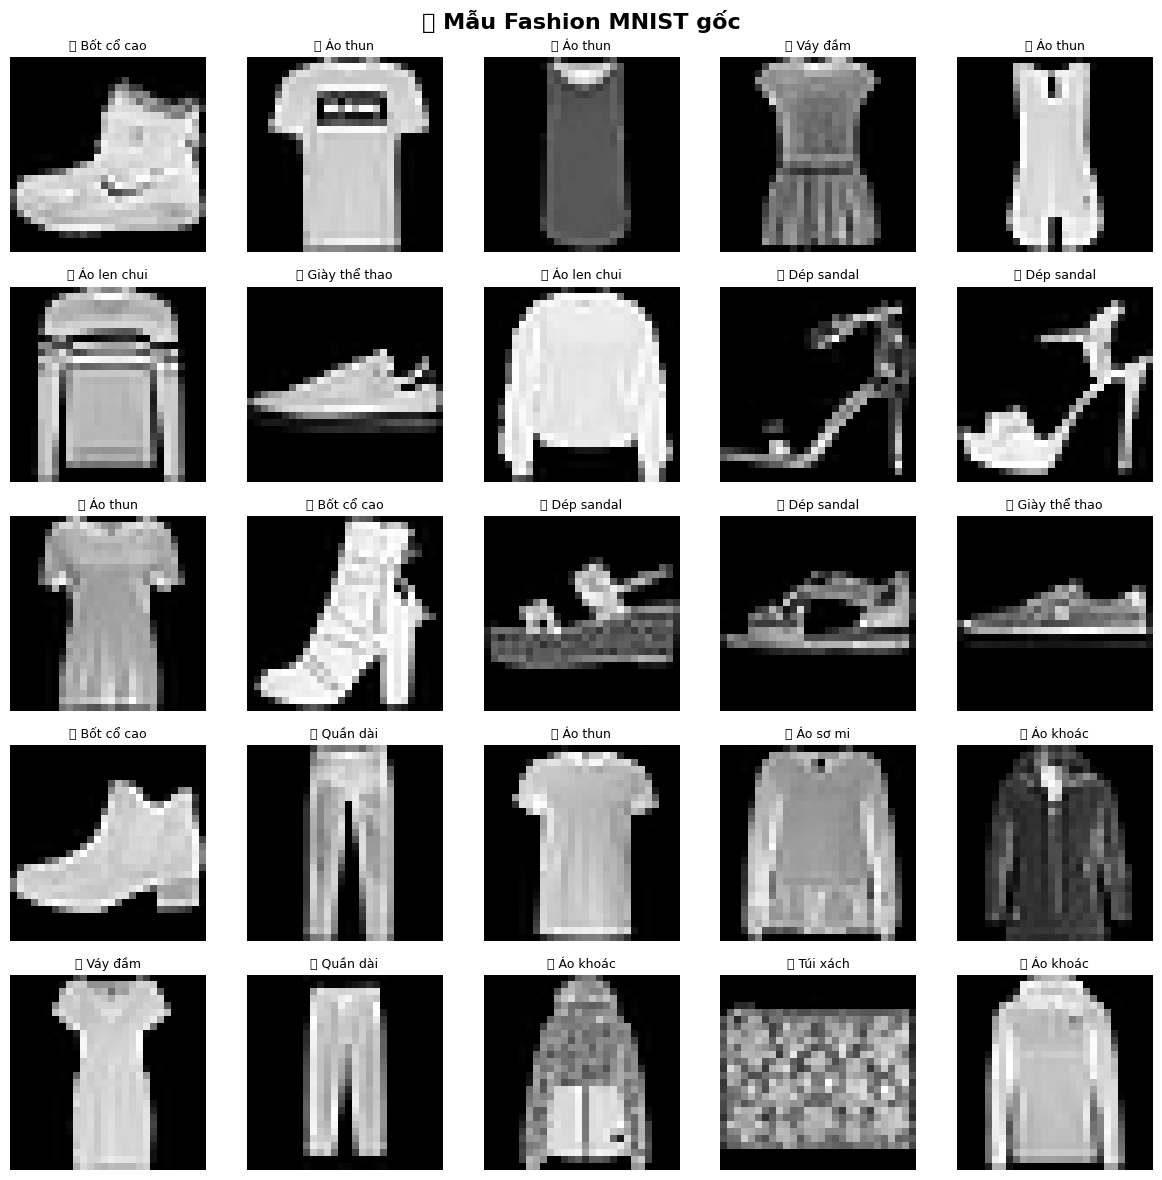


📊 Phân bố nhãn trong train set:
  👕 Áo thun             : 6000 ██████████████████████████████
  👖 Quần dài            : 6000 ██████████████████████████████
  🧥 Áo len chui         : 6000 ██████████████████████████████
  👗 Váy đầm             : 6000 ██████████████████████████████
  🧥 Áo khoác            : 6000 ██████████████████████████████
  👡 Dép sandal          : 6000 ██████████████████████████████
  👔 Áo sơ mi            : 6000 ██████████████████████████████
  👟 Giày thể thao       : 6000 ██████████████████████████████
  👜 Túi xách            : 6000 ██████████████████████████████
  👢 Bốt cổ cao          : 6000 ██████████████████████████████


In [ ]:
# Cell 3: Load Fashion MNIST và hiển thị mẫu
print('📥 Đang tải Fashion MNIST...')
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = fashion_mnist.load_data()
print(f'✅ Train: {x_train_raw.shape} | Test: {x_test_raw.shape}')

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.suptitle('🎽 Mẫu Fashion MNIST gốc', fontsize=16, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_raw[i], cmap='gray')
    ax.set_title(CLASS_NAMES_VI[y_train_raw[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/sample_mnist.png', dpi=80)
plt.show()

# Phân bố nhãn
print('\n📊 Phân bố nhãn trong train set:')
for i, name in enumerate(CLASS_NAMES_VI):
    cnt = np.sum(y_train_raw==i)
    bar = '█' * (cnt//200)
    print(f'  {name:22s}: {cnt} {bar}')

## 🏋️ Cell 4 — Load Data Drive + Train Model
> Tự động đọc `images/`, `myntradataset/`, `styles.csv` và gộp vào training set

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Load data Drive + Gộp + Train Model                  ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Đọc styles.csv để map ID ảnh → loại quần áo ─────────────────────
print('📋 Đọc styles.csv...')
styles_map = {}
for csv_f in glob.glob(os.path.join(DATA_DIR, '**', 'styles.csv'), recursive=True):
    try:
        df = pd.read_csv(csv_f, on_bad_lines='skip')
        if 'id' in df.columns and 'articleType' in df.columns:
            styles_map = dict(zip(df['id'].astype(str), df['articleType'].str.lower()))
            print(f'  ✅ {os.path.basename(csv_f)}: {len(styles_map)} items')
            # Xem phân bố
            top_types = df['articleType'].value_counts().head(10)
            print('  Top 10 articleType trong CSV:')
            for at, cnt in top_types.items():
                lbl = guess_label(at)
                mapped = f'→ {CLASS_NAMES_VI[lbl]}' if lbl is not None else '→ (không map được)'
                print(f'    {at:30s}: {cnt:5d} {mapped}')
    except Exception as e:
        print(f'  ❌ Lỗi: {e}')

if not styles_map:
    print('  ⚠️  Không tìm thấy styles.csv hoặc không có cột id/articleType')

# ── Scan và đọc ảnh ──────────────────────────────────────────────────
print('\n🖼️  Scan ảnh trong Drive...')
img_files = (
    glob.glob(os.path.join(DATA_DIR, '**', '*.jpg'),  recursive=True) +
    glob.glob(os.path.join(DATA_DIR, '**', '*.jpeg'), recursive=True) +
    glob.glob(os.path.join(DATA_DIR, '**', '*.png'),  recursive=True)
)
print(f'  Tìm thấy {len(img_files)} ảnh')

extra_x, extra_y = [], []
ok, skip_no_label, skip_err = 0, 0, 0
label_counts = [0]*10

for f in img_files:
    # Ưu tiên styles.csv (map ID → articleType)
    fname_id = os.path.splitext(os.path.basename(f))[0]
    label = None
    if fname_id in styles_map:
        label = guess_label(styles_map[fname_id])
    # Fallback: đoán từ tên folder/file
    if label is None:
        label = guess_label(f)
    if label is None:
        skip_no_label += 1
        continue
    try:
        arr = img_to_28x28(f)
        extra_x.append(arr.reshape(784))
        extra_y.append(label)
        label_counts[label] += 1
        ok += 1
    except:
        skip_err += 1

print(f'  ✅ {ok} ảnh đọc được | ⚠️ {skip_no_label} không có label | ❌ {skip_err} lỗi')

if ok > 0:
    print('\n  Phân bố data Drive theo nhãn:')
    for i, cnt in enumerate(label_counts):
        if cnt > 0:
            bar = '█' * min(cnt//10, 30)
            print(f'    {CLASS_NAMES_VI[i]:22s}: {cnt:5d}  {bar}')

# ── Đọc .npy / .npz ──────────────────────────────────────────────────
npy_count = 0
for f in glob.glob(os.path.join(DATA_DIR, '**', '*.npy'), recursive=True):
    try:
        arr = np.load(f, allow_pickle=True)
        fname = os.path.basename(f)
        if arr.ndim==2 and arr.shape[1]==785:
            lbls = arr[:,0].astype(int); pxs = arr[:,1:].astype('float32')
            if pxs.max()>1: pxs/=255.0
            extra_x.extend(pxs); extra_y.extend(lbls.tolist()); npy_count+=len(lbls)
        elif arr.ndim==2 and arr.shape[1]==784:
            lbl = guess_label(f)
            if lbl is not None:
                pxs = arr.astype('float32')
                if pxs.max()>1: pxs/=255.0
                extra_x.extend(pxs); extra_y.extend([lbl]*len(pxs)); npy_count+=len(pxs)
        elif arr.ndim==3 and arr.shape[1:]==(28,28):
            lbl = guess_label(f)
            if lbl is not None:
                pxs = arr.reshape(len(arr),784).astype('float32')
                if pxs.max()>1: pxs/=255.0
                extra_x.extend(pxs); extra_y.extend([lbl]*len(arr)); npy_count+=len(arr)
    except: pass

for f in glob.glob(os.path.join(DATA_DIR, '**', '*.npz'), recursive=True):
    try:
        d = np.load(f, allow_pickle=True)
        ks = list(d.keys())
        xk = next((k for k in ks if any(w in k.lower() for w in ['x','image','data','pixel'])), ks[0] if ks else None)
        yk = next((k for k in ks if any(w in k.lower() for w in ['y','label','class','target'])), ks[1] if len(ks)>1 else None)
        if xk and yk:
            xs = d[xk].reshape(len(d[xk]),-1).astype('float32')
            if xs.max()>1: xs/=255.0
            ys = d[yk].astype(int).flatten()
            extra_x.extend(xs); extra_y.extend(ys.tolist())
            npy_count += len(xs)
    except: pass

if npy_count > 0:
    print(f'\n  ✅ {npy_count} mẫu từ .npy/.npz')

# ── Gộp dữ liệu ──────────────────────────────────────────────────────
print('\n🔗 Gộp với Fashion MNIST gốc...')
x_mnist = x_train_raw.reshape(60000,784).astype('float32')/255.0
y_mnist  = y_train_raw.astype(int)

if extra_x:
    x_extra = np.array(extra_x, dtype='float32')
    y_extra = np.array(extra_y, dtype=int)
    valid = (y_extra>=0) & (y_extra<=9)
    x_extra, y_extra = x_extra[valid], y_extra[valid]
    x_train_all = np.concatenate([x_mnist, x_extra])
    y_train_all = np.concatenate([y_mnist, y_extra])
    print(f'  Fashion MNIST : {len(x_mnist):,} mẫu')
    print(f'  Data Drive    : {len(x_extra):,} mẫu')
    print(f'  Tổng cộng     : {len(x_train_all):,} mẫu')
else:
    print('⚠️  Không có data Drive. Chỉ dùng Fashion MNIST.')
    x_train_all, y_train_all = x_mnist, y_mnist

x_test_all = x_test_raw.reshape(10000,784).astype('float32')/255.0
y_test_all  = y_test_raw.astype(int)

perm = np.random.permutation(len(x_train_all))
x_train_all = x_train_all[perm]
y_train_all = y_train_all[perm]

Y_train = to_categorical(y_train_all, 10)
Y_test  = to_categorical(y_test_all, 10)

print(f'\n✅ Dataset sẵn sàng: {x_train_all.shape} train | {x_test_all.shape} test')

# ── Widget chọn cấu hình train ────────────────────────────────────────
CONFIGS = [
    {'name':'Model_A_Basic',  'layers':[512,256],       'dropout':False,'optimizer':'rmsprop'},
    {'name':'Model_B_Deeper', 'layers':[512,256,128],   'dropout':True, 'optimizer':'adam'},
    {'name':'Model_C_Wide',   'layers':[1024,512,256],  'dropout':True, 'optimizer':'adam'},
]

config_opts = {
    '🟢 Model A: Basic (512→256) — Nhanh nhất': 0,
    '🟡 Model B: Deeper (512→256→128) + Dropout': 1,
    '🔴 Model C: Wide (1024→512→256) + Dropout': 2,
    '🔵 Train TẤT CẢ và chọn cái tốt nhất': -1,
}

w_config = widgets.RadioButtons(
    options=list(config_opts.keys()),
    description='Cấu hình:',
    layout=widgets.Layout(width='500px')
)
w_epochs = widgets.IntSlider(
    value=10, min=5, max=30, step=5,
    description='Epochs:',
    style={'description_width':'initial'}
)
w_train_btn = widgets.Button(
    description='🚀 Bắt đầu Train',
    button_style='success',
    layout=widgets.Layout(width='200px', height='45px')
)
w_out = widgets.Output()

def build_model(cfg):
    m = Sequential(name=cfg['name'])
    m.add(Dense(cfg['layers'][0], activation='relu', input_shape=(784,)))
    if cfg['dropout']: m.add(Dropout(0.3))
    for u in cfg['layers'][1:]:
        m.add(Dense(u, activation='relu'))
        if cfg['dropout']: m.add(Dropout(0.2))
    m.add(Dense(10, activation='softmax'))
    m.compile(optimizer=cfg['optimizer'], loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def on_train(b):
    global model, all_train_results
    with w_out:
        clear_output()
        choice_idx = config_opts[w_config.value]
        epochs = w_epochs.value
        to_train = CONFIGS if choice_idx==-1 else [CONFIGS[choice_idx]]
        results = []

        for cfg in to_train:
            print(f'\n🏋️ Training {cfg["name"]}...')
            m = build_model(cfg)
            hist = m.fit(
                x_train_all, Y_train,
                epochs=epochs, batch_size=256, validation_split=0.15,
                callbacks=[
                    EarlyStopping(monitor='val_accuracy',patience=5,restore_best_weights=True),
                    ModelCheckpoint(best_model_path,save_best_only=True,monitor='val_accuracy',verbose=0)
                ],
                verbose=2
            )
            loss, acc = m.evaluate(x_test_all, Y_test, verbose=0)
            val_acc = max(hist.history['val_accuracy'])
            results.append({'name':cfg['name'],'model':m,'history':hist.history,'test_acc':acc,'val_acc':val_acc})
            print(f'✅ {cfg["name"]}: Test={acc*100:.2f}% | Val={val_acc*100:.2f}%')

        best = max(results, key=lambda r:r['test_acc'])
        model = best['model']
        model.save(best_model_path)
        all_train_results.extend(results)

        print('\n' + '='*55)
        print('🏆 KẾT QUẢ TRAIN')
        print('='*55)
        icons = ['🥇','🥈','🥉']
        for i, r in enumerate(sorted(results, key=lambda r:r['test_acc'], reverse=True)):
            icon = icons[i] if i<3 else '  '
            print(f'{icon} {r["name"]}: Test={r["test_acc"]*100:.2f}% | Val={r["val_acc"]*100:.2f}%')
        print(f'\n💾 Đã lưu: {best_model_path}')

        # Biểu đồ
        h = best['history']
        fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
        ax1.plot(h['accuracy'],'b-o',label='Train')
        ax1.plot(h['val_accuracy'],'r-o',label='Val')
        ax1.set_title(f'{best["name"]} — Accuracy ({best["test_acc"]*100:.2f}%)')
        ax1.legend(); ax1.grid(True); ax1.set_ylim(0,1)
        ax2.plot(h['loss'],'b-o',label='Train')
        ax2.plot(h['val_loss'],'r-o',label='Val')
        ax2.set_title(f'{best["name"]} — Loss')
        ax2.legend(); ax2.grid(True)
        plt.tight_layout()
        plt.savefig('/content/training_result.png', dpi=100)
        plt.show()

w_train_btn.on_click(on_train)
display(widgets.VBox([
    widgets.HTML(f'<b>📊 Dataset: {len(x_train_all):,} mẫu (MNIST {len(x_mnist):,} + Drive {len(x_train_all)-len(x_mnist):,})</b>'),
    w_config, w_epochs, w_train_btn, w_out
]))

## 📂 Cell 5 — Load Model từ file .h5

In [ ]:
# Cell 5: Load model từ file .h5
print('📂 LOAD MODEL TỪ FILE')

w_load_file = widgets.Button(description='📂 Upload .h5', button_style='info',
                              layout=widgets.Layout(width='180px', height='40px'))
w_load_best = widgets.Button(description='🏆 Load model tốt nhất', button_style='warning',
                              layout=widgets.Layout(width='200px', height='40px'))
w_load_out  = widgets.Output()

def on_load_file(b):
    global model
    with w_load_out:
        clear_output()
        uploaded = files.upload()
        for fname in uploaded:
            if fname.endswith(('.h5','.keras')):
                model = load_model(fname)
                x_te = x_test_raw.reshape(10000,784).astype('float32')/255
                y_te = to_categorical(y_test_raw,10)
                _, acc = model.evaluate(x_te, y_te, verbose=0)
                print(f'✅ Loaded: {fname} | Accuracy: {acc*100:.2f}%')
            else:
                print(f'❌ {fname} không phải .h5!')

def on_load_best(b):
    global model
    with w_load_out:
        clear_output()
        if os.path.exists(best_model_path):
            model = load_model(best_model_path)
            x_te = x_test_raw.reshape(10000,784).astype('float32')/255
            y_te = to_categorical(y_test_raw,10)
            _, acc = model.evaluate(x_te, y_te, verbose=0)
            print(f'✅ Loaded best model | Accuracy: {acc*100:.2f}%')
        else:
            print('❌ Chưa có model. Hãy Train (Cell 4) trước!')

w_load_file.on_click(on_load_file)
w_load_best.on_click(on_load_best)
display(widgets.VBox([widgets.HBox([w_load_file, w_load_best]), w_load_out]))

## 📊 Cell 6 — Accuracy chi tiết + Confusion Matrix

In [ ]:
# Cell 6: Accuracy chi tiết + Confusion Matrix
w_check_btn = widgets.Button(description='📊 Kiểm tra Accuracy', button_style='primary',
                              layout=widgets.Layout(width='220px', height='40px'))
w_check_out = widgets.Output()

def on_check(b):
    with w_check_out:
        clear_output()
        if model is None:
            print('❌ Chưa có model! Train hoặc Load trước.'); return

        x_te = x_test_raw.reshape(10000,784).astype('float32')/255
        y_te = to_categorical(y_test_raw,10)
        loss, acc = model.evaluate(x_te, y_te, verbose=0)
        preds = model.predict(x_te, verbose=0)
        pred_classes = np.argmax(preds, axis=1)

        print(f'🎯 Test Accuracy: {acc*100:.2f}% | Loss: {loss:.4f}\n')
        print('📋 Accuracy từng loại:')
        class_accs = []
        for i in range(10):
            mask = y_test_raw==i
            ca = np.mean(pred_classes[mask]==y_test_raw[mask])
            class_accs.append(ca)
            bar = '█'*int(ca*30) + '░'*(30-int(ca*30))
            print(f'  {CLASS_NAMES_VI[i]:22s}: {ca*100:5.1f}% |{bar}|')

        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_test_raw, pred_classes)
        cm_norm = cm.astype(float)/cm.sum(axis=1)[:,np.newaxis]

        fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))
        colors = plt.cm.RdYlGn(np.array(class_accs))
        bars = ax1.barh(CLASS_NAMES_VI, [a*100 for a in class_accs], color=colors)
        ax1.set_title(f'Accuracy từng loại (Tổng: {acc*100:.2f}%)', fontsize=13, fontweight='bold')
        ax1.set_xlabel('Accuracy (%)'); ax1.set_xlim(0,100)
        for bar,a in zip(bars,class_accs):
            ax1.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                     f'{a*100:.1f}%', va='center', fontweight='bold')
        im = ax2.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        ax2.set_xticks(range(10)); ax2.set_yticks(range(10))
        ax2.set_xticklabels(CLASS_NAMES_EN, rotation=45, ha='right', fontsize=8)
        ax2.set_yticklabels(CLASS_NAMES_EN, fontsize=8)
        ax2.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
        plt.colorbar(im, ax=ax2)
        for i in range(10):
            for j in range(10):
                ax2.text(j,i,f'{cm_norm[i,j]:.2f}',ha='center',va='center',
                         fontsize=6,color='white' if cm_norm[i,j]>0.5 else 'black')
        plt.tight_layout()
        plt.savefig('/content/accuracy_detail.png', dpi=100)
        plt.show()
        print(f'\n🏆 Tốt nhất: {CLASS_NAMES_VI[np.argmax(class_accs)]} ({max(class_accs)*100:.1f}%)')
        print(f'⚠️  Khó nhất: {CLASS_NAMES_VI[np.argmin(class_accs)]} ({min(class_accs)*100:.1f}%)')

w_check_btn.on_click(on_check)
display(widgets.VBox([w_check_btn, w_check_out]))

## 🖼️ Cell 7 — Upload ảnh và dự đoán

In [ ]:
# Cell 7: Upload ảnh bất kỳ và dự đoán
print('🖼️ UPLOAD ẢNH & DỰ ĐOÁN')

w_upload_btn = widgets.Button(description='📁 Upload ảnh',
                               button_style='primary',
                               layout=widgets.Layout(width='160px', height='40px'))
w_upload_out = widgets.Output()

def on_upload(b):
    with w_upload_out:
        clear_output()
        if model is None:
            print('❌ Chưa có model! Train hoặc Load trước.'); return
        print('📤 Chọn file ảnh (PNG, JPG, JPEG)...')
        uploaded = files.upload()
        for fname, fdata in uploaded.items():
            if fname.lower().split('.')[-1] in ['png','jpg','jpeg','bmp','webp']:
                pil = Image.open(io.BytesIO(fdata)).convert('RGB')
                img_array = np.array(pil)
                preds, img28 = predict_image(img_array)
                show_prediction(preds, img_array, img28)
            else:
                print(f'❌ {fname}: định dạng không hỗ trợ!')

w_upload_btn.on_click(on_upload)
display(widgets.VBox([w_upload_btn, w_upload_out]))

## ✏️ Cell 8 — Vẽ tay nhận dạng Real-time

In [ ]:
# Cell 8: Canvas vẽ bằng chuột - Nhận dạng real-time
DRAW_HTML = """
<div style="font-family:Arial,sans-serif;max-width:900px;margin:0 auto;">
  <h2 style="color:#2c3e50;text-align:center;">✏️ Vẽ Quần Áo — Nhận Dạng Real-time</h2>
  <p style="text-align:center;color:#7f8c8d;">Vẽ hình dạng quần áo (nền đen, nét trắng như Fashion MNIST)</p>
  <div style="display:flex;gap:20px;justify-content:center;align-items:flex-start;flex-wrap:wrap;">
    <div>
      <canvas id="drawCanvas" width="420" height="420"
        style="border:3px solid #2c3e50;border-radius:8px;cursor:crosshair;background:#000;display:block;"></canvas>
      <div style="display:flex;gap:8px;margin-top:10px;flex-wrap:wrap;">
        <button onclick="clearCanvas()" style="flex:1;padding:10px;background:#e74c3c;color:white;border:none;border-radius:6px;cursor:pointer;font-size:14px;">🗑️ Xóa</button>
        <button onclick="predictDrawing()" style="flex:2;padding:10px;background:#27ae60;color:white;border:none;border-radius:6px;cursor:pointer;font-size:14px;">🔍 Dự đoán</button>
        <button onclick="toggleAuto()" id="autoBtn" style="flex:2;padding:10px;background:#3498db;color:white;border:none;border-radius:6px;cursor:pointer;font-size:14px;">⚡ Auto mode</button>
      </div>
      <div style="margin-top:8px;display:flex;gap:8px;align-items:center;">
        <label style="font-size:13px;">Bút:</label>
        <input type="range" id="brushSize" min="5" max="40" value="20" style="width:100px;"
               oninput="document.getElementById('brushVal').textContent=this.value">
        <span id="brushVal" style="font-size:13px;font-weight:bold;">20</span>
        <button onclick="toggleEraser()" id="eraserBtn" style="padding:5px 10px;background:#95a5a6;color:white;border:none;border-radius:4px;cursor:pointer;">🔲 Tẩy</button>
      </div>
    </div>
    <div style="min-width:300px;">
      <div id="resultBox" style="border:2px solid #bdc3c7;border-radius:8px;padding:15px;background:#f8f9fa;min-height:200px;">
        <p style="color:#7f8c8d;text-align:center;">Vẽ hình quần áo và nhấn "Dự đoán"</p>
      </div>
      <div style="margin-top:15px;text-align:center;">
        <p style="font-size:12px;color:#7f8c8d;">Preview 28×28:</p>
        <canvas id="previewCanvas" width="140" height="140"
          style="border:2px solid #bdc3c7;border-radius:4px;image-rendering:pixelated;"></canvas>
      </div>
      <div style="margin-top:15px;background:#eaf4fb;border-radius:8px;padding:10px;">
        <p style="font-weight:bold;font-size:13px;margin:0 0 5px;">💡 Gợi ý vẽ:</p>
        <p style="font-size:12px;color:#555;margin:0;">
          • Áo thun: Hình chữ T<br>• Quần dài: 2 ống dài<br>
          • Váy: Hình tam giác/thang<br>• Giày: Hình oval ngang<br>• Túi: Hình chữ nhật + quai
        </p>
      </div>
    </div>
  </div>
</div>
<script>
var canvas=document.getElementById('drawCanvas'), ctx=canvas.getContext('2d');
var isDrawing=false, isEraser=false, autoMode=false, autoTimer=null;
ctx.fillStyle='#000'; ctx.fillRect(0,0,canvas.width,canvas.height);
var labels=[
  '👕 Áo thun','👖 Quần dài','🧥 Áo len chui','👗 Váy đầm','🧥 Áo khoác',
  '👡 Dép sandal','👔 Áo sơ mi','👟 Giày thể thao','👜 Túi xách','👢 Bốt cổ cao'
];
function getPos(e){
  var r=canvas.getBoundingClientRect(), sx=canvas.width/r.width, sy=canvas.height/r.height;
  if(e.touches) return {x:(e.touches[0].clientX-r.left)*sx, y:(e.touches[0].clientY-r.top)*sy};
  return {x:(e.clientX-r.left)*sx, y:(e.clientY-r.top)*sy};
}
canvas.addEventListener('mousedown',function(e){isDrawing=true;draw(e);});
canvas.addEventListener('mousemove',function(e){if(isDrawing)draw(e);});
canvas.addEventListener('mouseup',function(){isDrawing=false;ctx.beginPath();triggerAuto();});
canvas.addEventListener('mouseleave',function(){isDrawing=false;ctx.beginPath();});
canvas.addEventListener('touchstart',function(e){e.preventDefault();isDrawing=true;draw(e);},{passive:false});
canvas.addEventListener('touchmove',function(e){e.preventDefault();if(isDrawing)draw(e);},{passive:false});
canvas.addEventListener('touchend',function(){isDrawing=false;ctx.beginPath();triggerAuto();});
function draw(e){
  var p=getPos(e), size=parseInt(document.getElementById('brushSize').value);
  ctx.beginPath(); ctx.arc(p.x,p.y,size,0,Math.PI*2);
  ctx.fillStyle=isEraser?'#000':'#fff'; ctx.fill(); updatePreview();
}
function clearCanvas(){
  ctx.fillStyle='#000'; ctx.fillRect(0,0,canvas.width,canvas.height);
  document.getElementById('resultBox').innerHTML='<p style="color:#7f8c8d;text-align:center;">Canvas đã xóa!</p>';
  var pc=document.getElementById('previewCanvas').getContext('2d');
  pc.fillStyle='#000'; pc.fillRect(0,0,140,140);
}
function toggleEraser(){
  isEraser=!isEraser;
  var btn=document.getElementById('eraserBtn');
  btn.style.background=isEraser?'#e74c3c':'#95a5a6';
  btn.textContent=isEraser?'✏️ Bút':'🔲 Tẩy';
}
function toggleAuto(){
  autoMode=!autoMode;
  var btn=document.getElementById('autoBtn');
  btn.style.background=autoMode?'#e67e22':'#3498db';
  btn.textContent=autoMode?'⚡ Auto: BẬT':'⚡ Auto mode';
}
function updatePreview(){
  var pc=document.getElementById('previewCanvas').getContext('2d');
  pc.imageSmoothingEnabled=false; pc.clearRect(0,0,140,140);
  pc.drawImage(canvas,0,0,140,140);
}
function triggerAuto(){
  if(autoMode){ if(autoTimer)clearTimeout(autoTimer); autoTimer=setTimeout(predictDrawing,600); }
}
function predictDrawing(){
  var imgData=canvas.toDataURL('image/png');
  document.getElementById('resultBox').innerHTML='<p style="text-align:center;">⏳ Đang phân tích...</p>';
  google.colab.kernel.invokeFunction('predict_canvas',[imgData],{});
}
window.showResult=function(result){
  var data=JSON.parse(result), pred=data.predictions, topIdx=data.top_idx;
  var topConf=(pred[topIdx]*100).toFixed(1);
  var color=topConf>70?'#27ae60':topConf>50?'#e67e22':'#e74c3c';
  var html='<div style="text-align:center;">';
  html+='<div style="font-size:32px;font-weight:bold;color:'+color+';margin-bottom:5px;">'+labels[topIdx]+'</div>';
  html+='<div style="font-size:18px;font-weight:bold;">'+topConf+'%</div>';
  html+='<hr style="margin:10px 0;"><div style="text-align:left;font-size:12px;">';
  var sorted=pred.map((p,i)=>[i,p]).sort((a,b)=>b[1]-a[1]);
  sorted.slice(0,10).forEach(function(item,rank){
    var pct=(item[1]*100).toFixed(1), barW=Math.round(item[1]*150), isTop=rank===0;
    html+='<div style="margin:3px 0;display:flex;align-items:center;gap:5px;">';
    html+='<span style="width:130px;font-size:11px;'+(isTop?'font-weight:bold;':'')+'">'+(labels[item[0]])+'</span>';
    html+='<div style="width:'+barW+'px;height:12px;background:'+(isTop?'#27ae60':'#3498db')+';border-radius:2px;"></div>';
    html+='<span style="font-size:11px;'+(isTop?'font-weight:bold;':'')+'">'+(pct)+'%</span></div>';
  });
  html+='</div></div>';
  document.getElementById('resultBox').innerHTML=html;
};
</script>
"""

def predict_canvas(img_data_url):
    if model is None:
        output.eval_js('window.showResult(\'{"predictions":[0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1],"top_idx":0}\')')
        return
    header, b64 = img_data_url.split(',', 1)
    img = Image.open(io.BytesIO(base64.b64decode(b64))).convert('L')
    img28 = img.resize((28,28), Image.LANCZOS)
    arr = np.array(img28).astype('float32')/255
    preds = model.predict(arr.reshape(1,784), verbose=0)[0]
    top_idx = int(np.argmax(preds))
    result = json.dumps({'predictions':preds.tolist(),'top_idx':top_idx})
    output.eval_js(f'window.showResult({json.dumps(result)})')

output.register_callback('predict_canvas', predict_canvas)
print('✅ Canvas vẽ sẵn sàng!')
display(HTML(DRAW_HTML))

## 📷 Cell 9 — Camera nhận dạng Real-time

In [ ]:
# Cell 9: Camera real-time
CAMERA_HTML = """
<div style="font-family:Arial,sans-serif;max-width:900px;margin:0 auto;">
  <h2 style="color:#2c3e50;text-align:center;">📷 Camera Nhận Dạng Real-time</h2>
  <div style="display:flex;gap:20px;justify-content:center;flex-wrap:wrap;">
    <div>
      <video id="camVideo" width="400" height="300" autoplay style="border:3px solid #2c3e50;border-radius:8px;display:none;"></video>
      <canvas id="camCanvas" width="400" height="300" style="display:none;"></canvas>
      <div id="camPlaceholder" style="width:400px;height:300px;background:#2c3e50;border-radius:8px;display:flex;align-items:center;justify-content:center;">
        <p style="color:white;text-align:center;">📷<br>Nhấn Bật Camera</p>
      </div>
      <div style="position:relative;">
        <canvas id="camPreview" width="112" height="112"
          style="border:2px solid #bdc3c7;border-radius:4px;image-rendering:pixelated;margin-top:10px;"></canvas>
        <span style="font-size:11px;color:#7f8c8d;margin-left:8px;">Preview 28×28</span>
      </div>
      <div style="display:flex;gap:8px;margin-top:10px;flex-wrap:wrap;">
        <button onclick="startCamera()" style="flex:1;padding:10px;background:#27ae60;color:white;border:none;border-radius:6px;cursor:pointer;font-size:14px;">🎥 Bật Camera</button>
        <button onclick="captureAndPredict()" style="flex:2;padding:10px;background:#3498db;color:white;border:none;border-radius:6px;cursor:pointer;font-size:14px;">📸 Chụp & Dự đoán</button>
        <button onclick="toggleLive()" id="liveBtn" style="flex:2;padding:10px;background:#9b59b6;color:white;border:none;border-radius:6px;cursor:pointer;font-size:14px;">⚡ Live Mode</button>
      </div>
    </div>
    <div style="min-width:280px;">
      <div id="camResult" style="border:2px solid #bdc3c7;border-radius:8px;padding:15px;background:#f8f9fa;min-height:200px;">
        <p style="color:#7f8c8d;text-align:center;">Bật camera và chụp ảnh để nhận dạng</p>
      </div>
      <div id="camHistory" style="margin-top:15px;border:2px solid #bdc3c7;border-radius:8px;padding:10px;background:#fff;max-height:180px;overflow-y:auto;">
        <p style="color:#aaa;font-size:12px;text-align:center;">Lịch sử dự đoán</p>
      </div>
    </div>
  </div>
</div>
<script>
var video=document.getElementById('camVideo'), camCanvas=document.getElementById('camCanvas');
var camCtx=camCanvas.getContext('2d'), W=400, H=300;
var liveMode=false, liveTimer=null, historyCount=0;
var camLabels=[
  '👕 Áo thun','👖 Quần dài','🧥 Áo len chui','👗 Váy đầm','🧥 Áo khoác',
  '👡 Dép sandal','👔 Áo sơ mi','👟 Giày thể thao','👜 Túi xách','👢 Bốt cổ cao'
];
function startCamera(){
  navigator.mediaDevices.getUserMedia({video:{width:W,height:H,facingMode:'environment'}})
    .then(function(stream){
      video.srcObject=stream;
      document.getElementById('camPlaceholder').style.display='none';
      video.style.display='block';
    }).catch(function(e){ alert('Không bật được camera: '+e.message); });
}
function captureFrame(){
  camCtx.drawImage(video,0,0,W,H);
  var cs=Math.min(W,H)*0.5, cx=(W-cs)/2, cy=(H-cs)/2;
  var crop=camCtx.getImageData(cx,cy,cs,cs);
  var sc=document.createElement('canvas'); sc.width=28; sc.height=28;
  var sCtx=sc.getContext('2d'); sCtx.putImageData(crop,0,0);
  var pCtx=document.getElementById('camPreview').getContext('2d');
  pCtx.imageSmoothingEnabled=false; pCtx.drawImage(sc,0,0,112,112);
  return camCanvas.toDataURL('image/jpeg',0.8);
}
function captureAndPredict(){
  var imgData=captureFrame();
  document.getElementById('camResult').innerHTML='<p style="text-align:center;">⏳ Đang phân tích...</p>';
  google.colab.kernel.invokeFunction('predict_camera',[imgData],{});
}
function toggleLive(){
  liveMode=!liveMode;
  var btn=document.getElementById('liveBtn');
  if(liveMode){
    btn.textContent='⏹️ Dừng Live'; btn.style.background='#e74c3c';
    liveTimer=setInterval(captureAndPredict,2000);
  } else {
    btn.textContent='⚡ Live Mode'; btn.style.background='#9b59b6';
    clearInterval(liveTimer);
  }
}
window.showCamResult=function(result){
  var data=JSON.parse(result), pred=data.predictions, topIdx=data.top_idx;
  var topConf=(pred[topIdx]*100).toFixed(1);
  var color=topConf>70?'#27ae60':topConf>50?'#e67e22':'#e74c3c';
  var html='<div style="text-align:center;">';
  html+='<div style="font-size:30px;font-weight:bold;color:'+color+';margin-bottom:5px;">'+camLabels[topIdx]+'</div>';
  html+='<div style="font-size:20px;font-weight:bold;color:'+color+';">'+topConf+'%</div>';
  html+='<hr style="margin:8px 0;"><div style="text-align:left;font-size:11px;">';
  var sorted=pred.map((p,i)=>[i,p]).sort((a,b)=>b[1]-a[1]);
  sorted.slice(0,5).forEach(function(item){
    var pct=(item[1]*100).toFixed(1), barW=Math.round(item[1]*160);
    html+='<div style="margin:3px 0;display:flex;align-items:center;gap:5px;">';
    html+='<span style="width:130px;">'+camLabels[item[0]]+'</span>';
    html+='<div style="width:'+barW+'px;height:10px;background:#3498db;border-radius:2px;"></div>';
    html+='<span>'+pct+'%</span></div>';
  });
  html+='</div></div>';
  document.getElementById('camResult').innerHTML=html;
  historyCount++;
  var now=new Date().toLocaleTimeString();
  var hDiv=document.getElementById('camHistory');
  if(historyCount===1) hDiv.innerHTML='';
  var entry=document.createElement('div');
  entry.style.cssText='border-bottom:1px solid #eee;padding:3px 0;margin-bottom:2px;';
  entry.innerHTML='<span style="color:#999;">['+now+']</span> '+camLabels[topIdx]+' <b>('+topConf+'%)</b>';
  hDiv.insertBefore(entry,hDiv.firstChild);
  if(hDiv.children.length>20) hDiv.removeChild(hDiv.lastChild);
};
</script>
"""

def predict_camera(img_data_url):
    if model is None:
        output.eval_js('window.showCamResult(\'{"predictions":[0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1],"top_idx":0}\')')
        return
    header, b64 = img_data_url.split(',', 1)
    img = Image.open(io.BytesIO(base64.b64decode(b64))).convert('RGB')
    w, h = img.size
    crop = min(w,h)//2
    cx, cy = w//2, h//2
    img = img.crop((cx-crop//2,cy-crop//2,cx+crop//2,cy+crop//2))
    img_gray = img.convert('L').resize((28,28), Image.LANCZOS)
    arr = np.array(img_gray).astype('float32')/255
    if arr.mean()>0.5: arr = 1.0-arr
    preds = model.predict(arr.reshape(1,784), verbose=0)[0]
    top_idx = int(np.argmax(preds))
    result = json.dumps({'predictions':preds.tolist(),'top_idx':top_idx})
    output.eval_js(f'window.showCamResult({json.dumps(result)})')

output.register_callback('predict_camera', predict_camera)
print('✅ Giao diện Camera sẵn sàng!')
print('💡 Nhấn "Bật Camera" → hướng vào quần áo → nhấn "Chụp & Dự đoán"')
display(HTML(CAMERA_HTML))

## 💾 Cell 10 — Download model & kết quả

In [ ]:
# Cell 10: Download model và các file kết quả
print('💾 DOWNLOAD MODEL & KẾT QUẢ')

w_dl_model = widgets.Button(description='💾 Download Model (.h5)', button_style='success',
                             layout=widgets.Layout(width='220px'))
w_dl_chart = widgets.Button(description='📊 Download Biểu đồ Train', button_style='info',
                             layout=widgets.Layout(width='220px'))
w_dl_acc   = widgets.Button(description='📈 Download Accuracy Chart', button_style='warning',
                             layout=widgets.Layout(width='220px'))
w_dl_pred  = widgets.Button(description='🖼️ Download Kết quả dự đoán', button_style='primary',
                             layout=widgets.Layout(width='220px'))
w_dl_out   = widgets.Output()

def dl_model(b):
    with w_dl_out:
        clear_output()
        if os.path.exists(best_model_path):
            files.download(best_model_path)
            print(f'✅ Đang tải: {best_model_path}')
        else:
            print('❌ Chưa có model. Train trước!')

def dl_chart(b):
    with w_dl_out:
        clear_output()
        for f in ['/content/training_result.png', '/content/sample_mnist.png']:
            if os.path.exists(f): files.download(f); print(f'✅ {os.path.basename(f)}')

def dl_acc(b):
    with w_dl_out:
        clear_output()
        if os.path.exists('/content/accuracy_detail.png'):
            files.download('/content/accuracy_detail.png'); print('✅ accuracy_detail.png')
        else:
            print('❌ Chạy Cell 6 trước!')

def dl_pred(b):
    with w_dl_out:
        clear_output()
        if os.path.exists('/content/pred_result.png'):
            files.download('/content/pred_result.png'); print('✅ pred_result.png')
        else:
            print('❌ Chạy Cell 7 trước!')

w_dl_model.on_click(dl_model)
w_dl_chart.on_click(dl_chart)
w_dl_acc.on_click(dl_acc)
w_dl_pred.on_click(dl_pred)
display(widgets.VBox([
    widgets.HBox([w_dl_model, w_dl_chart]),
    widgets.HBox([w_dl_acc, w_dl_pred]),
    w_dl_out
]))

---
## 📋 Tóm tắt nhanh

**Luồng Gradio (giao diện đẹp, camera hoạt động):**
```
Cell 0 → Cell 1A → Cell 1B → bấm link
```

**Luồng notebook thuần (ipywidgets, đầy đủ tính năng):**
```
Cell 0 → Cell 2 → Cell 3 → Cell 4 → Cell 6 → Cell 7 → Cell 8 → Cell 9 → Cell 10
```

**Cấu trúc Drive được hỗ trợ:**
```
FashionFolder/
├── images/           ← ảnh .jpg (tên file = ID sẽ map qua styles.csv)
├── myntradataset/    ← subfolder chứa ảnh (tên folder = loại quần áo)
└── styles.csv        ← map: id,articleType,...
```

> ⚠️ Đổi `FOLDER_ID` trong Cell 0 thành ID folder Drive của bạn trước khi chạy!
